# Libraries

In [23]:
from pathlib import Path
import json
import random
import re
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

SEED = 42
random.seed(SEED)

SAMPLE_DIR = (Path("..") / "data" / "samples").resolve()
ANNOTATION_DIR = SAMPLE_DIR / "annotations"
IMAGE_DIR = SAMPLE_DIR / "images"
OCR_DIR = SAMPLE_DIR / "ocr"

TRAIN_PATH = ANNOTATION_DIR / "train_sample.json"
VAL_PATH = ANNOTATION_DIR / "val_sample.json"

print("Current folder:", Path.cwd())
print("Sample folder:", SAMPLE_DIR)
print("Train sample:", TRAIN_PATH.exists())
print("Val sample:", VAL_PATH.exists())
print("Image folder:", IMAGE_DIR.exists())
print("OCR folder:", OCR_DIR.exists())

Current folder: c:\Users\firma\Documents\LOCKIN\SP-DOCVQA\notebooks
Sample folder: C:\Users\firma\Documents\LOCKIN\SP-DOCVQA\data\samples
Train sample: True
Val sample: True
Image folder: True
OCR folder: True


# Annotation Function

In [24]:
def load_json(path):
    with Path(path).open("r", encoding="utf-8") as file:
        return json.load(file)

def get_records(payload):
    for key in ["data", "questions", "annotations"]:
        if isinstance(payload.get(key), list):
            return payload[key]
    raise KeyError(
        f"List anotasi tidak ditemukan. "
        f"Field tersedia: {list(payload.keys())}"
    )

def get_question(record):
    return str(record.get("question") or record.get("questions") or "").strip()

def get_answers(record):
    value = record.get("answers") or record.get("answer") or []
    if isinstance(value, str):
        value = [value]
    return [str(answer).strip() for answer in value if str(answer).strip()]

def get_question_types(record):
    value = record.get("question_types") or record.get("question_type") or record.get("questionTypes") or []
    if isinstance(value, str):
        value = [value]
    return [
        str(question_type).strip() for question_type in value if str(question_type).strip()
    ]

def get_doc_id(record):
    value = record.get("docId") or record.get("doc_id") or record.get("document_id") or record.get("image") or record.get("image_name") or ""
    return Path(str(value)).stem

def normalize_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

train_payload = load_json(TRAIN_PATH)
val_payload = load_json(VAL_PATH)

train_records = get_records(train_payload)
val_records = get_records(val_payload)

print("Train:", len(train_records))
print("Validation:", len(val_records))

print("\nField record:")
print(list(train_records[0].keys()))

display(train_records[0])

Train: 500
Validation: 100

Field record:
['questionId', 'question', 'question_types', 'image', 'docId', 'ucsf_document_id', 'ucsf_document_page_no', 'answers', 'data_split']


{'questionId': 11837,
 'question': 'What is the name of the company of Mr. Roger  Hofer?',
 'question_types': ['form'],
 'image': 'documents/sjng0065_3.png',
 'docId': 3855,
 'ucsf_document_id': 'sjng0065',
 'ucsf_document_page_no': '3',
 'answers': ['Philip Morris'],
 'data_split': 'train'}

# Data Information

In [25]:
def create_dataframes(records, split):
    question_rows = []
    answer_rows = []

    for index, record in enumerate(records):
        question = get_question(record)
        normalized_question = normalize_text(question)
        question_tokens = normalized_question.split()
        question_id = record.get("questionId") or record.get("question_id") or f"{split}-{index}"
        question_rows.append({
            "split": split,
            "question_id": question_id,
            "doc_id": get_doc_id(record),
            "question": question,
            "question_normalized": normalized_question,
            "question_length": len(question_tokens),
            "question_prefix_4gram": " ".join(question_tokens[:4]),
            "question_types": get_question_types(record),
            "number_of_answers": len(get_answers(record))
        })

        for answer in get_answers(record):
            normalized_answer = normalize_text(answer)
            answer_rows.append({
                "split": split,
                "question_id": question_id,
                "doc_id": get_doc_id(record),
                "answer": answer,
                "answer_normalized": normalized_answer,
                "answer_length": len(normalized_answer.split())
            })

    return pd.DataFrame(question_rows), pd.DataFrame(answer_rows)

df_train_question, df_train_answer = create_dataframes(train_records, "train")
df_val_question, df_val_answer = create_dataframes(val_records, "val")

df_question = pd.concat([df_train_question, df_val_question], ignore_index=True)
df_answer = pd.concat([df_train_answer, df_val_answer], ignore_index=True)

display(df_question.head())
display(df_answer.head())

,split,question_id,doc_id,question,question_normalized,question_length,question_prefix_4gram,question_types,number_of_answers
0,train,11837,3855,What is the name of the company of Mr. Roger ...,what is the name of the company of mr. roger h...,11,what is the name,[form],1
1,train,2813,1603,What is the area code for Godchaux-Henderson S...,what is the area code for godchaux-henderson s...,10,what is the area,[layout],1
2,train,28676,8286,What is the date on the document?,what is the date on the document?,7,what is the date,[layout],2
3,train,25872,7365,what is the mean intake of % of total calories...,what is the mean intake of % of total calories...,13,what is the mean,[table/list],1
4,train,23465,6827,what is the name of the university,what is the name of the university,7,what is the name,[layout],2


,split,question_id,doc_id,answer,answer_normalized,answer_length
0,train,11837,3855,Philip Morris,philip morris,2
1,train,2813,1603,205,205,1
2,train,28676,8286,"june 13, 1979","june 13, 1979",3
3,train,28676,8286,"June 13, 1979","june 13, 1979",3
4,train,25872,7365,45.0,45.0,1


## Summary

In [26]:
question_count = len(df_question)
document_count = df_question["doc_id"].nunique()

unique_question_percentage = df_question["question_normalized"].nunique() / question_count * 100
unique_answer_percentage = df_answer["answer_normalized"].nunique() / len(df_answer) * 100

df_summary = pd.DataFrame({
    "metric": [
        "Jumlah pertanyaan",
        "Jumlah dokumen",
        "Rata-rata pertanyaan per dokumen",
        "Rata-rata panjang pertanyaan",
        "Rata-rata panjang jawaban",
        "Pertanyaan unik (%)",
        "Jawaban unik (%)"
    ],
    "nilai": [
        question_count,
        document_count,
        question_count / document_count,
        df_question["question_length"].mean(),
        df_answer["answer_length"].mean(),
        unique_question_percentage,
        unique_answer_percentage
    ]
})
display(df_summary.round(2))

,metric,nilai
0,Jumlah pertanyaan,600.00
1,Jumlah dokumen,580.00
2,Rata-rata pertanyaan per dokumen,1.03
3,Rata-rata panjang pertanyaan,8.10
4,Rata-rata panjang jawaban,2.47
5,Pertanyaan unik (%),94.83
6,Jawaban unik (%),81.79


# EDA

## Distribusi question type

,question_type,count,percentage
0,layout,225,37.50
1,table/list,192,32.00
2,form,172,28.67
3,free_text,78,13.00
4,handwritten,32,5.33
5,others,16,2.67
6,figure/diagram,13,2.17
7,Image/Photo,7,1.17


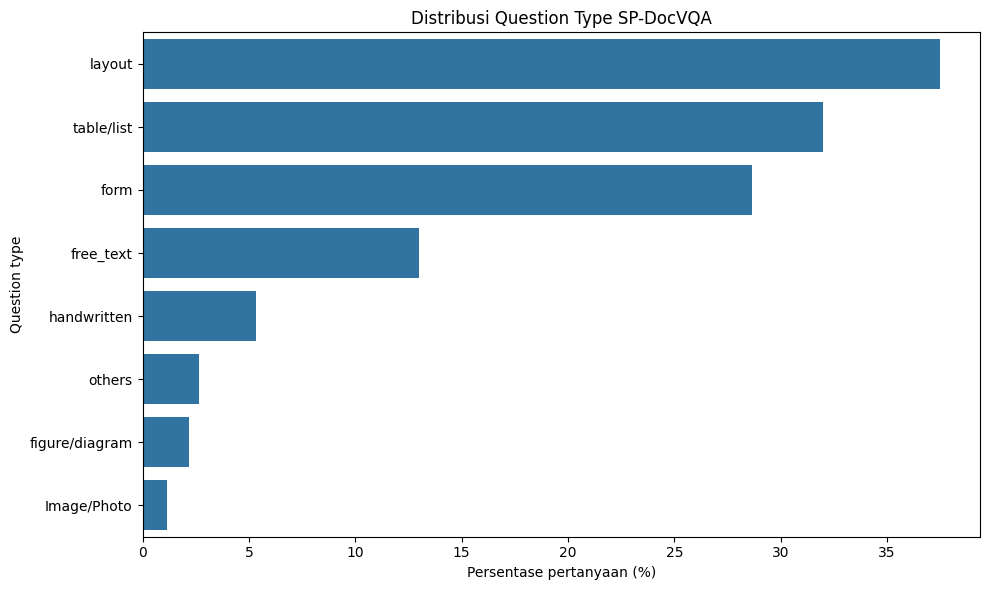

In [27]:
df_question_type = df_question.explode("question_types").dropna(subset=["question_types"])

question_type_counts = df_question_type["question_types"].value_counts().rename_axis("question_type").reset_index(name="count")
question_type_counts["percentage"] = question_type_counts["count"] / len(df_question) * 100
display(question_type_counts.round(2))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=question_type_counts,
    x="percentage",
    y="question_type"
)
plt.title("Distribusi Question Type SP-DocVQA")
plt.xlabel("Persentase pertanyaan (%)")
plt.ylabel("Question type")
plt.tight_layout()
plt.show()

## Pertanyaan dan jawaban teratas

,question,frequency
0,what is the page number?,9
1,what is the title of the document?,5
2,what is the date on the document?,4
3,what is the date?,3
4,what is the salutation of this letter?,3
5,what is the agreement effective date?,2
6,what is the office phone no mentioned in the a...,2
7,what is the title?,2
8,what is the page no mentioned in this document?,2
9,what is the date mentioned in the document?,2


,answer,frequency
0,2,6
1,250,3
2,transmit confirmation report,3
3,st. louis,3
4,washington university,3
5,1,3
6,paul berman,2
7,trust funds,2
8,general services - food distribution,2
9,mrs. daniela galli,2


,answer,frequency
0,washington university,3
1,st. louis,3
2,transmit confirmation report,3
3,saintregis new york,2
4,vanderbilt university,2
5,"june 13, 1979",2
6,minutes of yesterday's committee meeting,2
7,sunil agrawal,2
8,funds are coming in to you or your institution...,2
9,fmi workshop speakers,2


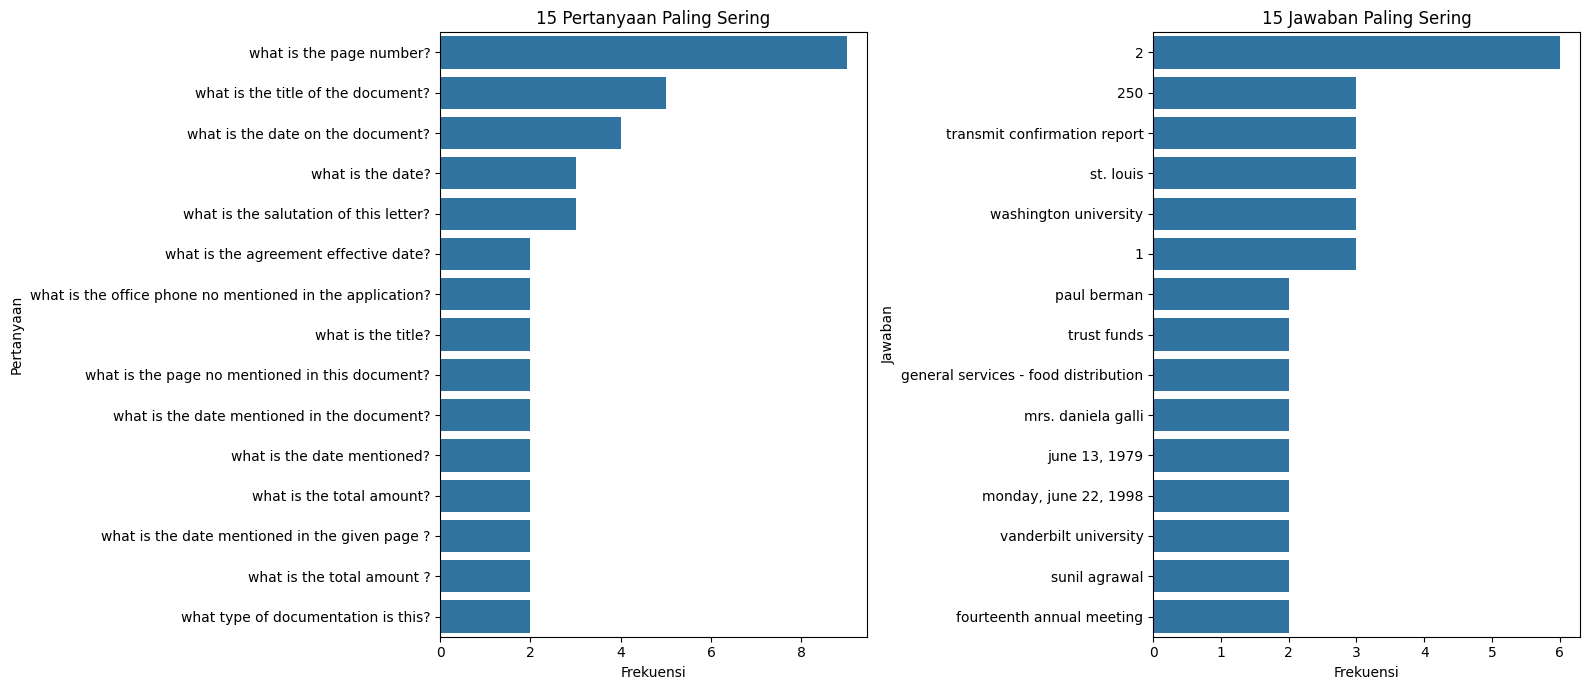

In [28]:
def frequency_table(series, column_name, n=15):
    return (
        series
        .value_counts()
        .head(n)
        .rename_axis(column_name)
        .reset_index(name="frequency")
    )

top_questions = frequency_table(df_question["question_normalized"], "question")
top_answers = frequency_table(df_answer["answer_normalized"], "answer")
non_numeric_answers = df_answer[df_answer["answer_normalized"].str.contains(r"[a-zA-Z]", regex=True, na=False)]
top_non_numeric_answers = frequency_table(non_numeric_answers["answer_normalized"], "answer")

display(top_questions)
display(top_answers)
display(top_non_numeric_answers)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(
    data=top_questions,
    x="frequency",
    y="question",
    ax=axes[0]
)

axes[0].set_title("15 Pertanyaan Paling Sering")
axes[0].set_xlabel("Frekuensi")
axes[0].set_ylabel("Pertanyaan")

sns.barplot(
    data=top_answers,
    x="frequency",
    y="answer",
    ax=axes[1]
)

axes[1].set_title("15 Jawaban Paling Sering")
axes[1].set_xlabel("Frekuensi")
axes[1].set_ylabel("Jawaban")

plt.tight_layout()
plt.show()

## Panjang pertanyaan dan jawaban

,length,frequency
0,3,2
1,4,33
2,5,73
3,6,85
4,7,96
5,8,84
6,9,68
7,10,52
8,11,35
9,12,27


,length,frequency
0,1,352
1,2,194
2,3,164
3,4,68
4,5,36
5,6,20
6,7,16
7,8,8
8,9,3
9,10,3


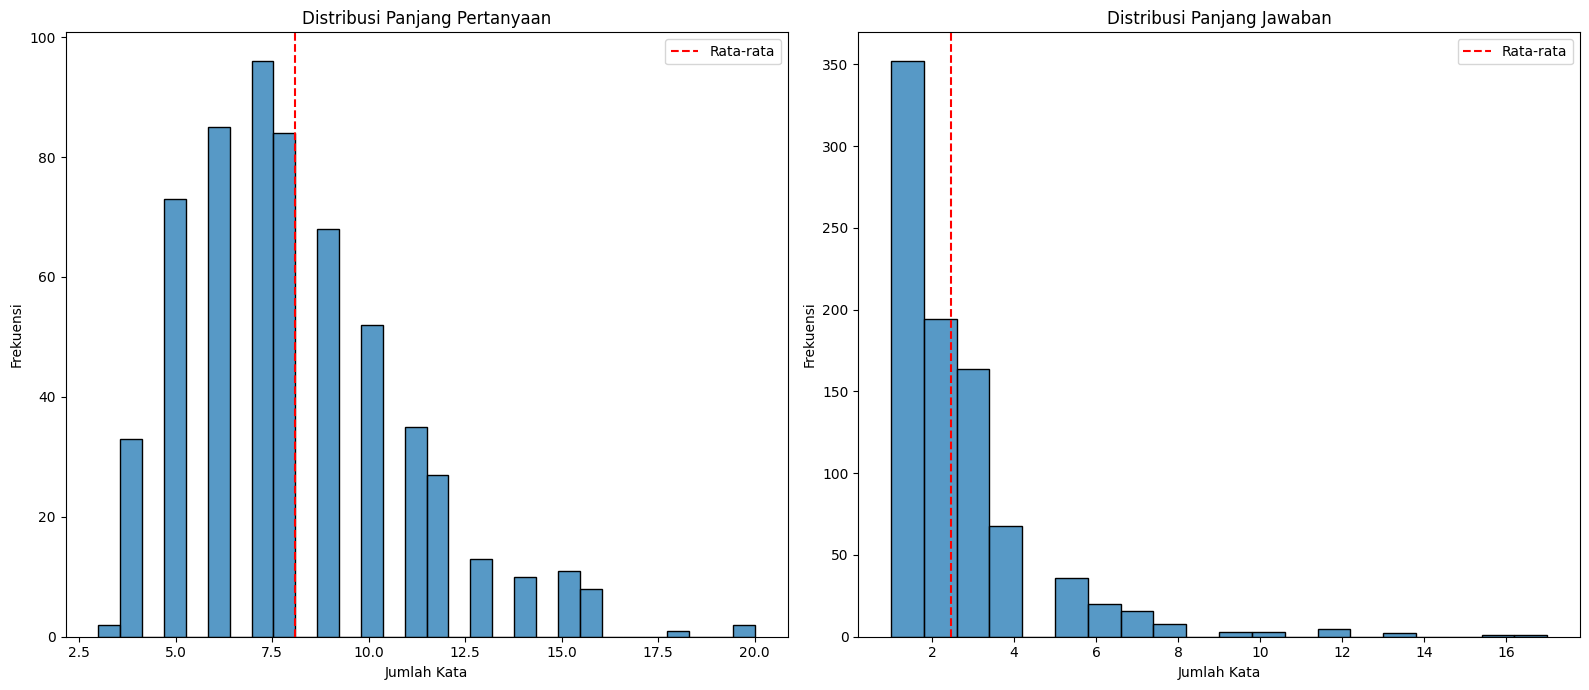

In [29]:
question_length_table = df_question["question_length"].value_counts().sort_index().rename_axis("length").reset_index(name="frequency")
answer_length_table = df_answer["answer_length"].value_counts().sort_index().rename_axis("length").reset_index(name="frequency")

display(question_length_table)
display(answer_length_table)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.histplot(
    data=df_question,
    x="question_length",
    bins=30,
    ax=axes[0]
)

axes[0].axvline(
    df_question["question_length"].mean(),
    color="red",
    linestyle="--",
    label="Rata-rata"
)

axes[0].set_title("Distribusi Panjang Pertanyaan")
axes[0].set_xlabel("Jumlah Kata")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()

sns.histplot(
    data=df_answer,
    x="answer_length",
    bins=20,
    ax=axes[1]
)

axes[1].axvline(
    df_answer["answer_length"].mean(),
    color="red",
    linestyle="--",
    label="Rata-rata"
)

axes[1].set_title("Distribusi Panjang Jawaban")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
axes[1].legend()

plt.tight_layout()
plt.show()

## Analisis OCR dan kecocokan jawaban

In [30]:
def build_file_index(directory, patterns):
    index = {}

    for pattern in patterns:
        for path in Path(directory).rglob(pattern):
            index.setdefault(path.stem.lower(), path)
            index.setdefault(path.name.lower(), path)

    return index

def get_candidate_names(record):
    candidates = [get_doc_id(record).lower()]

    image_name = record.get("image") or record.get("image_name")

    if image_name:
        candidates.append(Path(str(image_name)).stem.lower())

    return list(dict.fromkeys(candidates))

def find_file(index, record):
    for candidate in get_candidate_names(record):
        if candidate in index:
            return index[candidate]

    return None

def extract_ocr_words(payload):
    pages = (
        payload.get("recognitionResults")
        or payload.get("readResults")
        or payload.get("analyzeResult", {}).get("readResults")
        or []
    )

    output = []

    for page in pages:
        for line in page.get("lines", []):
            for word in line.get("words", []):
                text = str(word.get("text") or word.get("content") or "").strip()

                if text:
                    output.append({
                        "text": text,
                        "bounding_box": word.get("boundingBox") or word.get("polygon") or []
                    })

    return output

def compact_normalize(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()

    return "".join(character for character in text if character.isalnum())


ocr_index = build_file_index(OCR_DIR, ["*.json"])

print("Jumlah file OCR:", len(set(ocr_index.values())))

Jumlah file OCR: 580


In [31]:
all_records = (
    [("train", record) for record in train_records]
    + [("val", record) for record in val_records]
)

ocr_cache = {}
analysis_rows = []

for split, record in all_records:
    ocr_path = find_file(ocr_index, record)

    if ocr_path is None:
        analysis_rows.append({
            "split": split,
            "doc_id": get_doc_id(record),
            "question": get_question(record),
            "ocr_found": False,
            "ocr_token_count": None,
            "answer_found_in_ocr": False
        })
        continue

    if ocr_path not in ocr_cache:
        ocr_payload = load_json(ocr_path)
        ocr_cache[ocr_path] = extract_ocr_words(ocr_payload)

    words = ocr_cache[ocr_path]

    serialized_ocr = "".join(
        compact_normalize(word["text"])
        for word in words
    )

    normalized_answers = [compact_normalize(answer) for answer in get_answers(record)]

    answer_found = any(
        answer
        and answer in serialized_ocr
        for answer in normalized_answers
    )

    analysis_rows.append({
        "split": split,
        "doc_id": get_doc_id(record),
        "question": get_question(record),
        "ocr_found": True,
        "ocr_token_count": len(words),
        "answer_found_in_ocr": answer_found
    })

ocr_analysis_df = pd.DataFrame(analysis_rows)

display(ocr_analysis_df.head())

,split,doc_id,question,ocr_found,ocr_token_count,answer_found_in_ocr
0,train,3855,What is the name of the company of Mr. Roger ...,True,184,True
1,train,1603,What is the area code for Godchaux-Henderson S...,True,177,True
2,train,8286,What is the date on the document?,True,100,False
3,train,7365,what is the mean intake of % of total calories...,True,132,True
4,train,6827,what is the name of the university,True,120,True


,metric,value
0,Jumlah pertanyaan sample,600.00
1,Pertanyaan dengan OCR,600.00
2,OCR tidak ditemukan,0.00
3,Rata-rata token OCR per gambar,185.08
4,Jawaban ditemukan dalam OCR (%),92.67


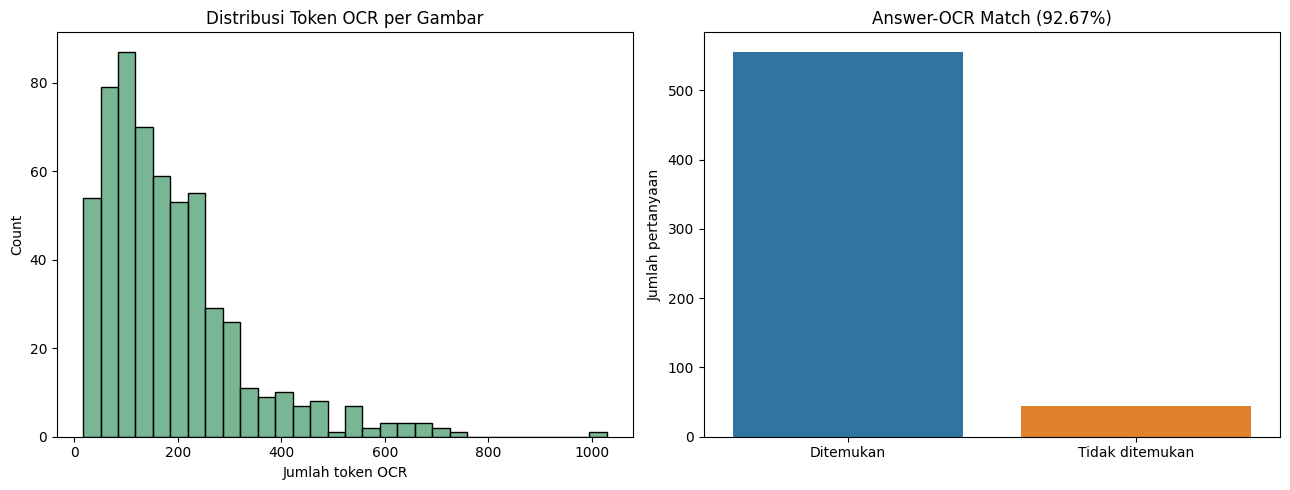

In [32]:
available_ocr_df = ocr_analysis_df[ocr_analysis_df["ocr_found"]].copy()

document_ocr_df = available_ocr_df[["doc_id", "ocr_token_count"]].drop_duplicates("doc_id")

if len(available_ocr_df) > 0:
    answer_match_percentage = available_ocr_df["answer_found_in_ocr"].mean() * 100
else:
    answer_match_percentage = 0

ocr_summary_df = pd.DataFrame({
    "metric": [
        "Jumlah pertanyaan sample",
        "Pertanyaan dengan OCR",
        "OCR tidak ditemukan",
        "Rata-rata token OCR per gambar",
        "Jawaban ditemukan dalam OCR (%)"
    ],
    "value": [
        len(ocr_analysis_df),
        len(available_ocr_df),
        (~ocr_analysis_df["ocr_found"]).sum(),
        document_ocr_df["ocr_token_count"].mean(),
        answer_match_percentage
    ]
})

display(ocr_summary_df.round(2))

if len(available_ocr_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.histplot(
        document_ocr_df["ocr_token_count"],
        bins=30,
        color="#4C9F70",
        ax=axes[0]
    )

    axes[0].set_title("Distribusi Token OCR per Gambar")
    axes[0].set_xlabel("Jumlah token OCR")

    match_status = (
        available_ocr_df["answer_found_in_ocr"]
        .map({
            True: "Ditemukan",
            False: "Tidak ditemukan"
        })
        .value_counts()
        .rename_axis("status")
        .reset_index(name="count")
    )

    sns.barplot(
        data=match_status,
        x="status",
        y="count",
        hue="status",
        legend=False,
        ax=axes[1]
    )

    axes[1].set_title(f"Answer-OCR Match ({answer_match_percentage:.2f}%)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Jumlah pertanyaan")

    plt.tight_layout()
    plt.show()

## Preview dokumen sample

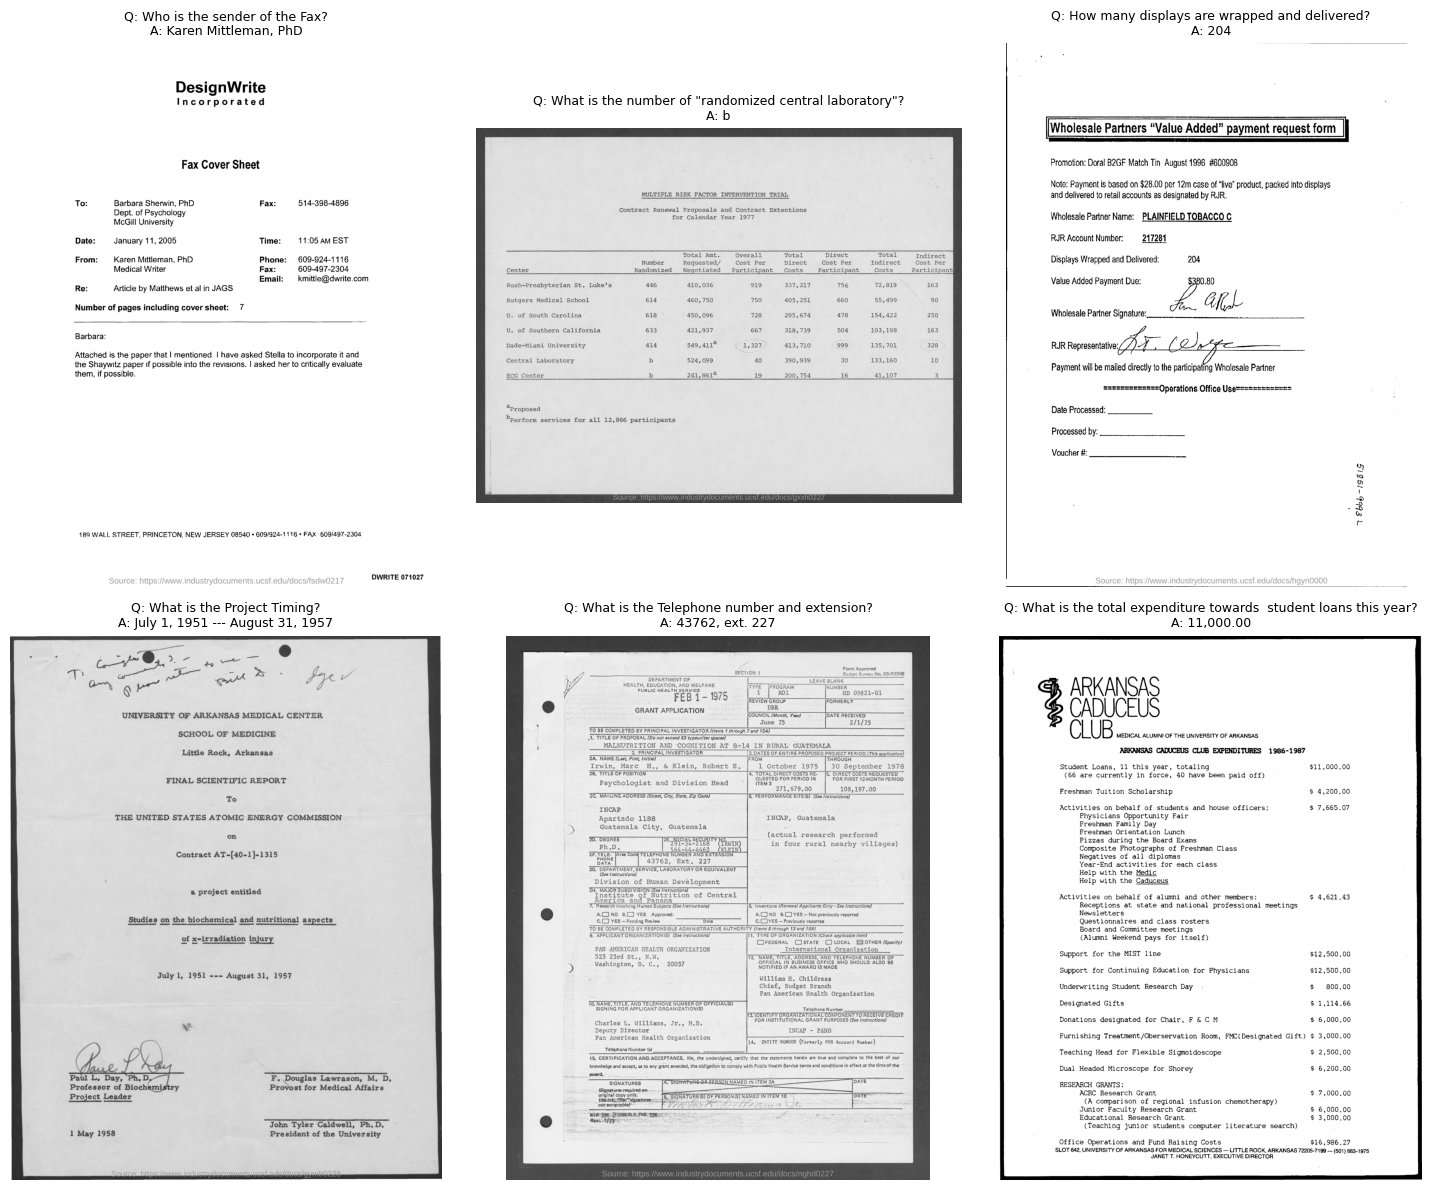

In [33]:
image_index = build_file_index(IMAGE_DIR, ["*.png", "*.jpg", "*.jpeg"])

preview_records = random.sample(
    [record for _, record in all_records],
    min(6, len(all_records))
)

fig, axes = plt.subplots(2, 3, figsize=(15, 12))

axes = axes.flatten()

for axis in axes:
    axis.axis("off")

for axis, record in zip(axes, preview_records):
    image_path = find_file(image_index, record)

    if image_path is None:
        axis.text(
            0.5,
            0.5,
            f"Gambar {get_doc_id(record)} "
            f"tidak ditemukan",
            ha="center",
            va="center"
        )

        continue

    image = Image.open(image_path).convert("RGB")

    answer_list = get_answers(record)
    answer = answer_list[0] if answer_list else "-"

    axis.imshow(image)
    axis.axis("off")

    axis.set_title(
        f"Q: {get_question(record)}\n"
        f"A: {answer}",
        fontsize=9
    )

plt.tight_layout()
plt.show()